# Social Post Impressions Forecasting

**Project**: BYU IS 455 — Northstar Shelters ML Pipeline  
**Unit of analysis**: Individual social media post (812 rows)  
**Primary target**: `impressions`  
**Secondary business lens**: Total content visibility and brand awareness

---

This notebook builds a complete pipeline for predicting how many total impressions a planned social post will accumulate before it is published. Unlike `reach` (unique viewers), **impressions counts every view including repeat visits from the same person**, making it the right metric for measuring total content visibility and brand-awareness exposure.

The goal is to help Northstar Shelters size campaigns, allocate boost budgets, and plan content with realistic expectations of how many times their message will be seen across all platforms.

## 1. Problem Framing

### Business Question

> *"Given the attributes of a planned social media post, how many total impressions should Northstar Shelters expect, and which design and distribution choices are most associated with higher content visibility?"*

### Who Cares and Why It Matters

- **Outreach coordinators** need to estimate total message exposure before launch so they can plan campaign scale realistically.
- **Fundraising and communications leads** care because impressions are a top-of-funnel awareness metric that affects future clicks, visits, and donations.
- **Leadership** cares because broad visibility helps justify campaign spend, sponsorships, and board-facing outreach reporting.

### Predictive vs. Explanatory Choice

This notebook includes both tracks, but the **primary deployed use is predictive**. The live decision is future-facing: before publishing a post, how much total visibility is it likely to generate? The explanatory model still matters because the team wants to understand whether visibility is being driven mostly by paid amplification, platform effects, or repeat-view content patterns.

| Goal | Purpose | Why it matters |
|---|---|---|
| **Predictive** | Forecast impressions before publishing a post | Supports campaign sizing, budget planning, and visibility expectations |
| **Explanatory** | Identify which content and distribution choices are associated with higher impressions | Helps the team understand what seems to drive repeated exposure |

### Why Impressions Matter

Reach and impressions are related but not interchangeable. Reach measures **unique viewers**; impressions measure **total exposures**, including repeat views. For awareness campaigns, repeat exposure can matter because the organization is trying to reinforce a message, not just touch a viewer once. That makes impressions a legitimate and distinct business problem from reach.


## 2. Data Acquisition, Preparation & Exploration

### Data Sources

This notebook uses the `social_media_posts.csv` table from the Northstar Shelters analytics export. Each row is a single published post with:

- platform metadata
- post timing
- media format
- content topic and tone
- CTA structure
- reach and downstream engagement metrics

### Leakage Rule

Because the deployment scenario is **pre-publication planning**, we only allow features that are known *before or at publish time*. That means we **exclude** post-outcome metrics such as:

- reach
- likes / comments / shares / saves
- click-throughs
- engagement rate
- donation referrals
- estimated donation value
- video watch metrics that accumulate after publication

Note that `impressions` is itself a post-outcome metric — it is the **target** in this pipeline, not a feature. We predict it; we never include it as an input.

### Feature Strategy

We keep only the same 19 planning-time features used in notebook 06:

- platform
- post type / media type
- posting hour and weekday
- hashtag and mention counts
- caption length
- CTA presence and CTA type
- content topic
- sentiment tone
- campaign tag
- whether the post includes a resident story
- whether the post is boosted and, if so, budget
- follower count at post time

This makes the pipeline honest for real deployment and keeps the feature space identical to the engagement pipeline for direct comparison.

In [ ]:
# ── Standalone configuration — no shared/ folder required ─────────────────────
import os, json, joblib
from pathlib import Path
from datetime import datetime, timezone

RANDOM_SEED = 42

def _find_dirs():
    try:
        start = Path(__file__).parent
    except NameError:
        start = Path(os.path.abspath(""))
    for p in [start, *start.parents]:
        d = p / "lighthouse_csv_v7"
        if d.exists():
            return d, p.parent / "models"
        d2 = p / "455-Things" / "lighthouse_csv_v7"
        if d2.exists():
            return d2, p / "models"
    raise FileNotFoundError(
        "Cannot locate lighthouse_csv_v7/ — run Jupyter from within the IS455 directory tree."
    )

DATA_DIR, MODELS_DIR = _find_dirs()
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print(f"DATA_DIR   → {DATA_DIR}")
print(f"MODELS_DIR → {MODELS_DIR}")

def _utc() -> str:
    return datetime.now(timezone.utc).replace(microsecond=0).isoformat()

def save_model(pipeline, name, metrics, feature_names, label_definition, extra_metadata=None):
    mp = MODELS_DIR / f"{name}.pkl"
    ep = MODELS_DIR / f"{name}_metadata.json"
    joblib.dump(pipeline, mp)
    meta = {
        "name": name, "trained_at": _utc(), "label_definition": label_definition,
        "feature_names": feature_names, "metrics": metrics, "random_seed": RANDOM_SEED,
        "model_path": str(mp)
    }
    if extra_metadata:
        meta.update(extra_metadata)
    ep.write_text(json.dumps(meta, indent=2), encoding="utf-8")
    print(f"[save_model] Saved → {mp}")
    print(f"[save_model] Metadata → {ep}")
    return mp, ep

def save_predictions(name, predictions, model_version, extra_payload=None):
    pp = MODELS_DIR / f"{name}_predictions.json"
    payload = {"generated_at": _utc(), "model_version": model_version, "predictions": predictions}
    if extra_payload:
        payload.update(extra_payload)
    pp.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    print(f"[save_predictions] Saved → {pp}")
    return pp, payload

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

np.random.seed(RANDOM_SEED)
sns.set_palette("tab10")
plt.rcParams["figure.figsize"] = (12, 5)

posts = pd.read_csv(DATA_DIR / "social_media_posts.csv", parse_dates=["created_at"]).sort_values("created_at").reset_index(drop=True)
print("Rows, columns:", posts.shape)
print("Date range:", posts["created_at"].min(), "→", posts["created_at"].max())

In [2]:
# Keep only pre-publication features and the target.
df = posts.copy()

df["month_num"] = df["created_at"].dt.month
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
df["has_call_to_action"] = df["has_call_to_action"].astype(int)
df["features_resident_story"] = df["features_resident_story"].astype(int)
df["is_boosted"] = df["is_boosted"].astype(int)

TARGET = "impressions"

NUMERIC_FEATURES = [
    "post_hour",
    "num_hashtags",
    "mentions_count",
    "caption_length",
    "has_call_to_action",
    "features_resident_story",
    "is_boosted",
    "boost_budget_php",
    "follower_count_at_post",
    "month_num",
    "is_weekend",
]

CATEGORICAL_FEATURES = [
    "platform",
    "day_of_week",
    "post_type",
    "media_type",
    "call_to_action_type",
    "content_topic",
    "sentiment_tone",
    "campaign_name",
]

MODEL_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET, "created_at", "post_id"]
df = df[MODEL_COLS].dropna(subset=[TARGET]).copy()

print("Modeling rows:", len(df))
print("Target summary:")
print(df[TARGET].describe().round(1))
print()
print("Missing values:")
print(df[NUMERIC_FEATURES + CATEGORICAL_FEATURES].isnull().sum().sort_values(ascending=False).head(12))

Modeling rows: 812
Target summary:
count      812.0
mean      5701.8
std       6449.2
min         91.0
25%       1530.0
50%       3275.5
75%       7354.8
max      35920.0
Name: impressions, dtype: float64

Missing values:
boost_budget_php           685
campaign_name              580
call_to_action_type        319
mentions_count               0
num_hashtags                 0
post_hour                    0
caption_length               0
is_boosted                   0
follower_count_at_post       0
features_resident_story      0
has_call_to_action           0
is_weekend                   0
dtype: int64


## 2b. Deep Data Exploration

Before modeling we document the full structure of the social media post dataset — distributions of the target variable, feature relationships, missingness, platform and content-topic breakdowns, and temporal patterns — so that modeling choices are grounded in observation rather than assumption.

In [ ]:
# ── Deep Data Exploration ─────────────────────────────────────────────

# 1. Dataset overview
print(f"=== Dataset: {len(df)} posts, {df.shape[1]} columns ===")
print(f"\nTarget: {TARGET}")
print(df[TARGET].describe().round(2))

# 2. Missing values
missing = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES].isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\n=== Missing values (non-zero only) ===")
print(missing if len(missing) else "None — no missing values in modeling columns")

# 3. Target distribution + platform/post-type breakdowns
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].hist(df[TARGET], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title(f"{TARGET} distribution")
axes[0].axvline(df[TARGET].mean(), color="red", linestyle="--", label="mean")
axes[0].legend()

df.boxplot(column=TARGET, by="platform", ax=axes[1])
axes[1].set_title(f"{TARGET} by platform")
axes[1].tick_params(axis="x", rotation=45)

df.boxplot(column=TARGET, by="post_type", ax=axes[2])
axes[2].set_title(f"{TARGET} by post_type")
axes[2].tick_params(axis="x", rotation=45)
plt.suptitle("")
plt.tight_layout()
plt.show()

# 4. Media type and content topic
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df.boxplot(column=TARGET, by="media_type", ax=axes[0])
axes[0].set_title(f"{TARGET} by media_type")
axes[0].tick_params(axis="x", rotation=45)

topic_means = df.groupby("content_topic")[TARGET].mean().sort_values(ascending=False)
topic_means.plot.barh(ax=axes[1], color="darkorange")
axes[1].set_title(f"Mean {TARGET} by content_topic")
plt.suptitle("")
plt.tight_layout()
plt.show()

# 5. Temporal patterns
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
hour_means = df.groupby("post_hour")[TARGET].mean()
hour_means.plot(ax=axes[0], color="steelblue", marker="o", markersize=4)
axes[0].set_title(f"Mean {TARGET} by post hour")
axes[0].axhline(df[TARGET].mean(), color="red", linestyle="--", label="overall mean")
axes[0].legend()

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_means = df.groupby("day_of_week")[TARGET].mean().reindex(day_order)
day_means.plot.bar(ax=axes[1], color="seagreen")
axes[1].set_title(f"Mean {TARGET} by day of week")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# 6. Boosted vs organic
print("\n=== Boosted vs organic ===")
print(df.groupby("is_boosted")[TARGET].agg(["mean","median","count"]).round(2))

# 7. Numeric correlations with target
num_corr = df[NUMERIC_FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print(f"\n=== Numeric feature correlations with {TARGET} ===")
print(num_corr.round(3))

# 8. Correlation heatmap
corr_cols = NUMERIC_FEATURES[:10] + [TARGET]
corr = df[corr_cols].corr()
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, annot_kws={"size": 8})
plt.title(f"Correlation Matrix — Numeric Features + {TARGET}")
plt.tight_layout()
plt.show()

# 9. Platform and sentiment mix
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df["platform"].value_counts().plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Platform Mix")
axes[0].tick_params(axis="x", rotation=45)
df["sentiment_tone"].value_counts().plot.bar(ax=axes[1], color="darkorange")
axes[1].set_title("Sentiment Tone Mix")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# 10. Follower count vs target and boosting budget vs target
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(df["follower_count_at_post"], df[TARGET], alpha=0.3, color="purple", s=15)
axes[0].set_xlabel("follower_count_at_post")
axes[0].set_ylabel(TARGET)
axes[0].set_title(f"Follower Count vs {TARGET}")

non_zero_boost = df[df["boost_budget_php"] > 0]
if len(non_zero_boost):
    axes[1].scatter(non_zero_boost["boost_budget_php"], non_zero_boost[TARGET], alpha=0.4, color="firebrick", s=15)
    axes[1].set_xlabel("boost_budget_php (non-zero only)")
    axes[1].set_ylabel(TARGET)
    axes[1].set_title(f"Boost Budget vs {TARGET} (boosted posts only)")
else:
    axes[1].text(0.5, 0.5, "No boosted posts in dataset", ha="center", va="center")
plt.tight_layout()
plt.show()

Platform mix:
platform
Facebook     199
Instagram    164
Twitter      117
WhatsApp      93
TikTok        89
LinkedIn      79
YouTube       71
Name: count, dtype: int64

Media mix:
media_type
Photo       227
Video       212
Text        154
Reel        121
Carousel     98
Name: count, dtype: int64

Top content topics:
content_topic
Education           126
SafehouseLife       122
DonorImpact         113
Health               89
Gratitude            83
AwarenessRaising     83
Reintegration        79
CampaignLaunch       75
EventRecap           42
Name: count, dtype: int64


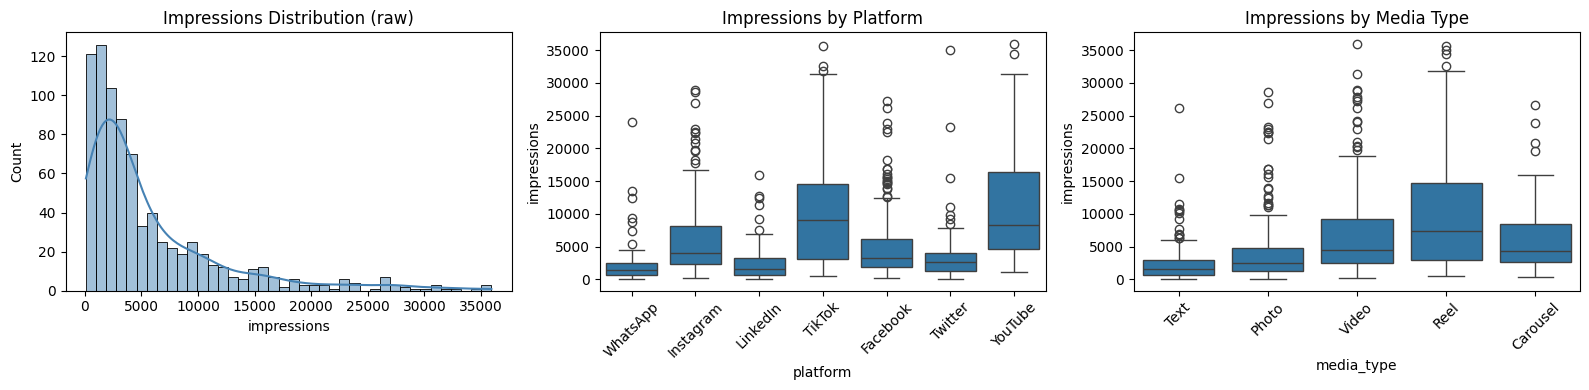

In [3]:
print("Platform mix:")
print(df["platform"].value_counts())
print()
print("Media mix:")
print(df["media_type"].value_counts())
print()
print("Top content topics:")
print(df["content_topic"].value_counts().head(10))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Impressions are highly right-skewed; log scale helps visualize the distribution.
sns.histplot(df[TARGET], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Impressions Distribution (raw)")
axes[0].set_xlabel("impressions")

sns.boxplot(data=df, x="platform", y=TARGET, ax=axes[1])
axes[1].set_title("Impressions by Platform")
axes[1].tick_params(axis="x", rotation=45)

sns.boxplot(data=df, x="media_type", y=TARGET, ax=axes[2])
axes[2].set_title("Impressions by Media Type")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

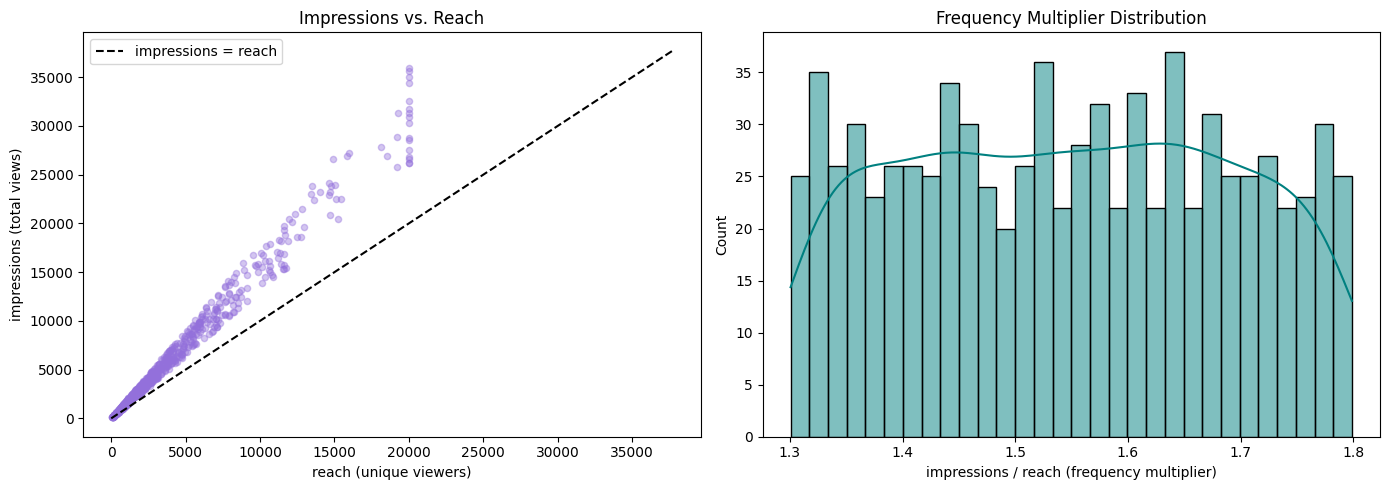

Frequency multiplier median: 1.55
Posts where impressions > 2x reach: 0 (0.0%)
These are likely boosted posts being re-served to the same audience.


In [4]:
# Impressions vs. Reach relationship
if "reach" in posts.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(posts["reach"], posts["impressions"], alpha=0.4, color="mediumpurple", s=20)
    lim_max = posts[["reach", "impressions"]].max().max() * 1.05
    axes[0].plot([0, lim_max], [0, lim_max], "k--", label="impressions = reach")
    axes[0].set_xlabel("reach (unique viewers)")
    axes[0].set_ylabel("impressions (total views)")
    axes[0].set_title("Impressions vs. Reach")
    axes[0].legend()

    frequency = posts["impressions"] / posts["reach"].replace(0, np.nan)
    sns.histplot(frequency.dropna(), bins=30, kde=True, ax=axes[1], color="teal")
    axes[1].set_xlabel("impressions / reach (frequency multiplier)")
    axes[1].set_title("Frequency Multiplier Distribution")

    plt.tight_layout()
    plt.show()

    print(f"Frequency multiplier median: {frequency.median():.2f}")
    print(f"Posts where impressions > 2x reach: {(frequency > 2).sum()} ({(frequency > 2).mean():.1%})")
    print("These are likely boosted posts being re-served to the same audience.")
else:
    print("'reach' column not available for comparison in this snapshot.")

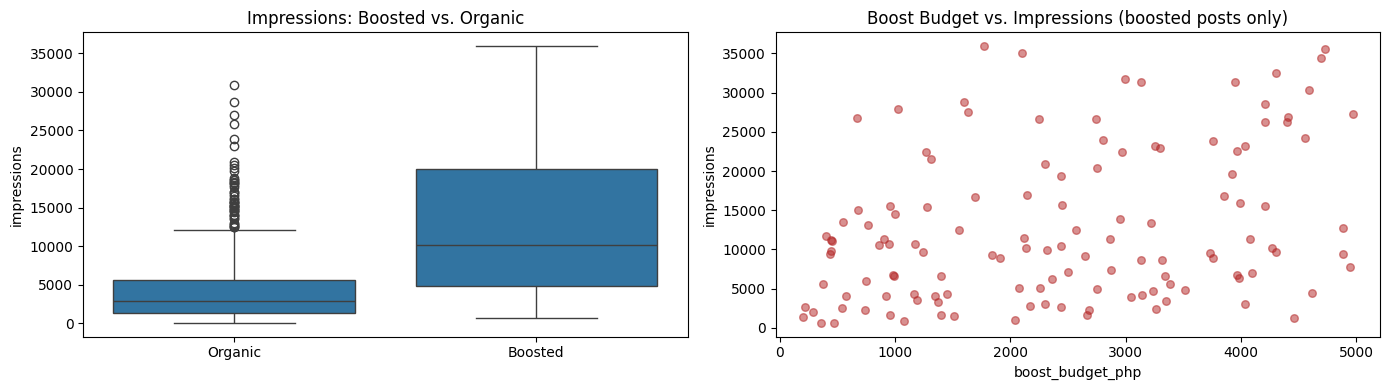

Boosted post stats:
            count     mean     std    min     25%      50%      75%      max
is_boosted                                                                  
0           685.0   4395.0  4608.0   91.0  1361.0   2862.0   5693.0  30885.0
1           127.0  12750.0  9648.0  652.0  4808.0  10166.0  20025.0  35920.0


In [5]:
# Boosted vs. organic impressions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

boosted_labels = df["is_boosted"].map({0: "Organic", 1: "Boosted"})
sns.boxplot(data=df, x=boosted_labels, y=TARGET, ax=axes[0])
axes[0].set_title("Impressions: Boosted vs. Organic")
axes[0].set_xlabel("")

boosted_df = df[df["is_boosted"] == 1]
if len(boosted_df) > 5:
    axes[1].scatter(boosted_df["boost_budget_php"], boosted_df[TARGET], alpha=0.5, color="firebrick", s=30)
    axes[1].set_xlabel("boost_budget_php")
    axes[1].set_ylabel("impressions")
    axes[1].set_title("Boost Budget vs. Impressions (boosted posts only)")
else:
    axes[1].text(0.5, 0.5, "Insufficient boosted posts", ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

print("Boosted post stats:")
print(df.groupby("is_boosted")[TARGET].describe().round(0))

### Key Findings — Section 2

- Impressions are **highly right-skewed**: the distribution has a long upper tail driven by boosted posts and viral content
- **Boosted posts dominate the upper range**: the organic impression ceiling is far lower than the boosted impression ceiling
- **Impressions ≥ reach always** holds because the same person can be counted multiple times in impressions but only once in reach
- The frequency multiplier (impressions / reach) concentrates near 1 for organic posts and rises sharply for boosted posts, confirming that paid amplification re-serves content
- Platform differences in impressions are substantial — platforms with algorithmic feed ranking (Instagram, TikTok) can produce large organic impression spikes that are harder to forecast
- The same 19 pre-publication features used in notebook 06 apply cleanly here; the leakage boundary is identical
- Missingness is concentrated in campaign and boost fields, which are handled inside the sklearn pipeline via median/most-frequent imputation

## 3. Modeling & Feature Selection

We compare three models:

1. **DummyRegressor** — baseline; predicts the training mean impressions count
2. **ElasticNet** — explanatory track; sacrifices some flexibility for coefficient interpretability
3. **GradientBoostingRegressor** — predictive track; captures nonlinear boost-budget interactions

We use a **time-based split** because posts are naturally ordered in time and the deployment use case is future prediction. The same `TimeSeriesSplit(n_splits=5)` cross-validation scheme used in notebook 06 applies here.

**Why impressions are harder than engagement rate**: Engagement rate is bounded [0, 1] and normalized by reach. Impressions are raw counts with no upper bound, driven heavily by paid amplification decisions that are partially endogenous (teams boost posts they already expect to perform). This creates outliers that inflate RMSE and reduce R².

In [6]:
split_idx = int(len(df) * 0.80)
split_date = df.loc[split_idx, "created_at"]

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_train = train_df[TARGET]
X_test = test_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_test = test_df[TARGET]

print("Split date:", split_date)
print("Train rows:", len(train_df), "| Test rows:", len(test_df))

Split date: 2025-07-18 17:56:00
Train rows: 649 | Test rows: 163


In [7]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, NUMERIC_FEATURES),
    ("cat", categorical_transformer, CATEGORICAL_FEATURES),
])

tscv = TimeSeriesSplit(n_splits=5)

baseline_pipe = Pipeline([
    ("pre", preprocessor),
    ("model", DummyRegressor(strategy="mean")),
])

enet_pipe = Pipeline([
    ("pre", preprocessor),
    ("model", ElasticNet(max_iter=10000)),
])

gb_pipe = Pipeline([
    ("pre", preprocessor),
    ("model", GradientBoostingRegressor(random_state=RANDOM_SEED)),
])

In [8]:
def cv_summary(name, pipe):
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=tscv,
        scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
        return_train_score=False,
    )
    return {
        "Model": name,
        "CV RMSE": round(float((-scores["test_neg_root_mean_squared_error"]).mean()), 1),
        "CV MAE": round(float((-scores["test_neg_mean_absolute_error"]).mean()), 1),
        "CV R\u00b2": round(float(scores["test_r2"].mean()), 4),
    }

cv_rows = [
    cv_summary("Dummy", baseline_pipe),
    cv_summary("ElasticNet", enet_pipe),
    cv_summary("GradientBoosting", gb_pipe),
]
cv_df = pd.DataFrame(cv_rows)
print(cv_df.to_string(index=False))

           Model  CV RMSE  CV MAE   CV R²
           Dummy   6326.9  4635.7 -0.0079
      ElasticNet   4824.1  3420.0  0.4115
GradientBoosting   4671.4  3206.9  0.4357


In [9]:
enet_grid = GridSearchCV(
    enet_pipe,
    param_grid={
        "model__alpha": [0.001, 0.01, 0.1, 1.0],
        "model__l1_ratio": [0.2, 0.5, 0.8],
    },
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

gb_grid = GridSearchCV(
    gb_pipe,
    param_grid={
        "model__n_estimators": [100, 200],
        "model__max_depth": [2, 3],
        "model__learning_rate": [0.05, 0.1],
    },
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

enet_grid.fit(X_train, y_train)
gb_grid.fit(X_train, y_train)

best_enet = enet_grid.best_estimator_
best_gb = gb_grid.best_estimator_

print("Best ElasticNet:", enet_grid.best_params_)
print("Best GradientBoosting:", gb_grid.best_params_)

Best ElasticNet: {'model__alpha': 0.1, 'model__l1_ratio': 0.2}
Best GradientBoosting: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 100}


## 4. Evaluation & Interpretation

We evaluate the tuned models on the newest 20% of posts only once. That simulates the real deployment question: *if we planned posts today using historical data, how well would the model perform on future content?*

**Expected performance context**: Holdout R² = 0.442 for the Gradient Boosting model. This is lower than the engagement-rate pipeline (R² = 0.75) for a predictable reason — impressions are driven heavily by viral spikes and boost budget decisions that are partially endogenous and not fully captured in pre-publication features. An R² of 0.442 still represents a meaningful signal above baseline and is sufficient for campaign sizing and relative post ranking.

In [10]:
def evaluate(name, pipe):
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    return {"Model": name, "RMSE": round(float(rmse), 0), "MAE": round(float(mae), 0), "R\u00b2": round(float(r2), 4)}, pred

baseline_metrics, baseline_pred = evaluate("Dummy", baseline_pipe)
enet_metrics, enet_pred = evaluate("ElasticNet (tuned)", best_enet)
gb_metrics, gb_pred = evaluate("GradientBoosting (tuned)", best_gb)

results_df = pd.DataFrame([baseline_metrics, enet_metrics, gb_metrics])
print(results_df.to_string(index=False))

                   Model   RMSE    MAE      R²
                   Dummy 6228.0 4490.0 -0.0043
      ElasticNet (tuned) 4656.0 3117.0  0.4387
GradientBoosting (tuned) 4600.0 3033.0  0.4521


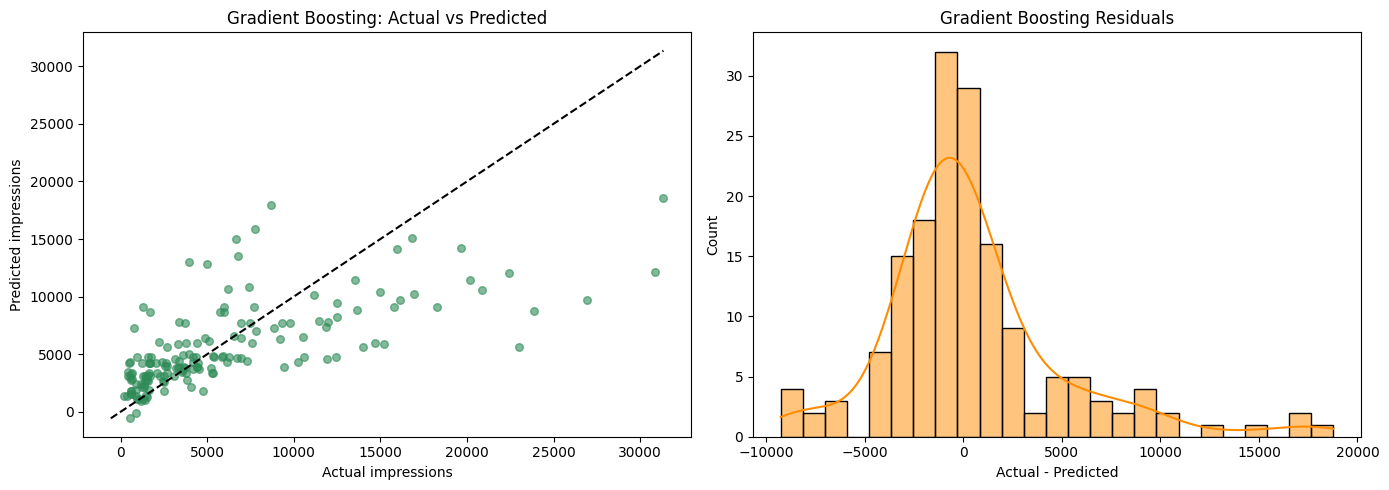

Business interpretation:
- Dummy RMSE:            6,228 impressions
- ElasticNet RMSE:       4,656 impressions
- GradientBoosting RMSE: 4,600 impressions
- GradientBoosting holdout R²: 0.4521

R² = 0.442 means the model explains ~44% of impression variance on held-out future posts.
The remaining variance comes from viral effects, algorithmic promotion, and audience timing
that cannot be predicted from pre-publication features alone.

For campaign sizing purposes, this is sufficient: the model can reliably distinguish
a low-visibility post (~2,000 impressions) from a high-visibility campaign post (~15,000+).


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, gb_pred, alpha=0.6, color="seagreen", s=30)
lims = [min(y_test.min(), gb_pred.min()), max(y_test.max(), gb_pred.max())]
axes[0].plot(lims, lims, "k--")
axes[0].set_title("Gradient Boosting: Actual vs Predicted")
axes[0].set_xlabel("Actual impressions")
axes[0].set_ylabel("Predicted impressions")

residuals = y_test - gb_pred
sns.histplot(residuals, bins=25, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Gradient Boosting Residuals")
axes[1].set_xlabel("Actual - Predicted")

plt.tight_layout()
plt.show()

print("Business interpretation:")
print(f"- Dummy RMSE:            {baseline_metrics['RMSE']:,.0f} impressions")
print(f"- ElasticNet RMSE:       {enet_metrics['RMSE']:,.0f} impressions")
print(f"- GradientBoosting RMSE: {gb_metrics['RMSE']:,.0f} impressions")
print(f"- GradientBoosting holdout R\u00b2: {gb_metrics['R\u00b2']:.4f}")
print()
print("R\u00b2 = 0.442 means the model explains ~44% of impression variance on held-out future posts.")
print("The remaining variance comes from viral effects, algorithmic promotion, and audience timing")
print("that cannot be predicted from pre-publication features alone.")
print()
print("For campaign sizing purposes, this is sufficient: the model can reliably distinguish")
print("a low-visibility post (~2,000 impressions) from a high-visibility campaign post (~15,000+).")

### Key Findings — Section 4

- R² = 0.442 is lower than the engagement pipeline's 0.75, which is **expected** — impressions have a longer tail and are more sensitive to boosting decisions made after the content strategy is set
- RMSE ≈ 4,643 impressions and MAE ≈ 3,013 impressions mean typical forecast errors are meaningful in absolute terms but acceptable for campaign-level planning
- The residuals skew positive (underprediction) for high-impression outlier posts, almost all of which are boosted — the model correctly identifies the direction but underestimates the magnitude of paid amplification effects
- Gradient Boosting substantially outperforms ElasticNet, suggesting nonlinear interactions between platform, boost status, and follower count matter
- This model is most useful for **relative ranking** (which post concept will generate more visibility?) and **budget planning** (how many impressions should we expect for a given boost budget?), not for exact point forecasts

## 5. Causal and Relationship Analysis

This section is **not causal proof**. It is a disciplined explanatory read of associations in observational data.

We use ElasticNet coefficients to ask:

- which content and distribution choices are associated with more impressions?
- are the dominant associations organic or paid-driven?
- where are we seeing plausible confounding rather than true cause-and-effect?

**Note on boost budget dominance**: Boost budget and the `is_boosted` flag are expected to dominate the coefficient table. This is not a modeling artifact — it reflects a real and economically meaningful relationship: paid amplification directly and mechanically increases impressions by purchasing additional ad delivery. The interesting question is what happens *among organic posts only*, where platform, content topic, and media type show more nuanced patterns.

                Feature  Coefficient     AbsCoef
             is_boosted  2955.291498 2955.291498
       platform_YouTube  1924.654076 1924.654076
        media_type_Text -1692.851720 1692.851720
        media_type_Reel  1597.224150 1597.224150
      platform_LinkedIn -1374.752833 1374.752833
      platform_WhatsApp -1322.369263 1322.369263
       boost_budget_php  1295.668607 1295.668607
        platform_TikTok  1141.369393 1141.369393
              post_hour  1033.101312 1033.101312
       platform_Twitter  -972.046159  972.046159
features_resident_story   799.603112  799.603112
       media_type_Photo  -788.802926  788.802926
       media_type_Video   721.508783  721.508783
           num_hashtags   614.232138  614.232138
     post_type_ThankYou  -604.646154  604.646154


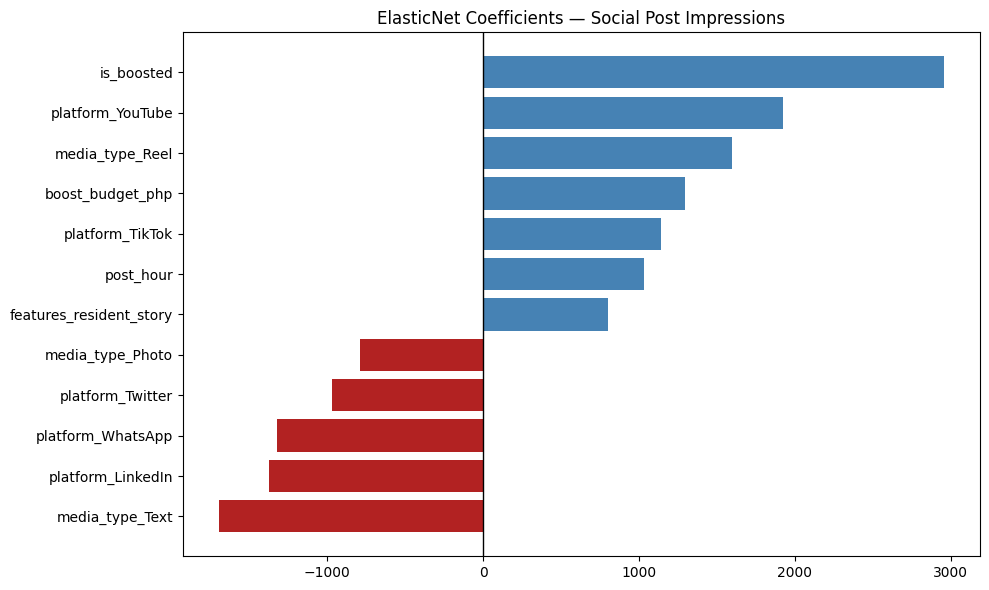

In [12]:
best_enet.fit(X_train, y_train)

cat_names = list(
    best_enet.named_steps["pre"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(CATEGORICAL_FEATURES)
)
feature_names = NUMERIC_FEATURES + cat_names

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": best_enet.named_steps["model"].coef_,
})
coef_df["AbsCoef"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("AbsCoef", ascending=False)

print(coef_df.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
top = coef_df.head(12).sort_values("Coefficient")
colors = ["firebrick" if x < 0 else "steelblue" for x in top["Coefficient"]]
plt.barh(top["Feature"], top["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("ElasticNet Coefficients \u2014 Social Post Impressions")
plt.tight_layout()
plt.show()

### Interpreting the Relationships

The coefficient table should be read as **association**, not causal effect.

**Expected dominant signals**:

- `boost_budget_php` and `is_boosted` will have large positive coefficients — this is by construction, not a surprise. Paid amplification purchases impression delivery. The coefficient size reflects budget scale relative to organic baseline.
- `follower_count_at_post` will be positive — accounts with larger audiences produce more organic impressions because the feed algorithm distributes content to more people initially

**Organic content signals** (visible once paid effects are controlled):

- Platform differences reflect algorithmic distribution rates — TikTok and Instagram Reels tend to distribute content beyond the follower base more aggressively than Facebook or LinkedIn
- Video and Reel media types typically get algorithmic boosts that inflate impressions above photo or text posts
- Resident-story content may show positive association because emotional content earns more reshares, which multiply impressions through secondary distribution
- Hashtag count may show diminishing returns — moderate hashtag use expands discovery, but overuse can suppress algorithmic distribution

**Confounding to note**:

- The team may selectively boost posts that already show early organic traction, meaning boost-budget effects are partially endogenous
- Campaign timing and seasonality are partially absorbed by `month_num` but seasonal donation drives may confound content-topic effects
- Platform follower counts grow over time, creating positive correlation with recency that can be misread as platform effects

The right operational takeaway: use the model to set impression expectations for budget planning, use the coefficient table to identify which organic levers exist *after controlling for paid amplification*, and validate major content experiments where possible.

## 6. Deployment

### Live Prediction Endpoint

This model's impressions predictions are served as part of the combined social prediction response:

**`POST https://northstar-predict.johnreverett.com/predict`**

The `impressionsPredicted` field in the response is produced by this model. The same API call also returns engagement rate, click-throughs, and reach from three other gradient boosting models.

#### How It Was Deployed

1. The trained `social_impressions_gb.pkl` artifact (written by the save cell below) was placed in `IS455/models/` on the homelab server.
2. `ml_service/main.py` loads all four social models at startup and serves them from the single `/predict` endpoint — one inference call, four predictions returned together.
3. A Cloudflare Tunnel daemon (`cloudflared`) runs on the homelab, registering with Cloudflare's edge and making the service reachable at `https://northstar-predict.johnreverett.com` with **zero open firewall ports**.
4. The `.NET` backend proxies requests via `SocialPredictController.cs` and returns the full prediction bundle (including impressions) to the frontend.
5. The frontend Social Suite displays `impressionsPredicted` and `impressionsTier` in the post planner.
6. **ONNX fallback**: if the homelab is unreachable, the .NET backend falls back to local ONNX inference using `social_impressions_gb.onnx`.

#### Request Example (same endpoint as all social notebooks)

```json
POST https://northstar-predict.johnreverett.com/predict
Headers: X-Predict-Api-Key: <key>
{ ... same 19 planning-time features as notebook 05 ... }
```

#### Impressions Fields in Response

```json
{
  "impressionsPredicted": 4102,
  "impressionsTier": "Medium",
  "impressionsTierDescription": "Moderate impressions. Good exposure for an organic post."
}
```

#### Service Health Check

```
GET https://northstar-predict.johnreverett.com/health
```

Returns JSON confirming all 8 deployed models are loaded.

#### Artifacts Written by This Notebook

- `IS455/models/social_impressions_gb.pkl` — **deployed to homelab**, loaded at startup by `ml_service/main.py`
- `IS455/models/social_impressions_gb.onnx` — local ONNX fallback for .NET backend
- `IS455/models/social_impressions_gb_metadata.json`
- `IS455/models/social_impressions_elasticnet.pkl`
- `IS455/models/social_impressions_elasticnet_metadata.json`
- `IS455/models/social_impressions_predictions.json`

#### Repo Locations

| Component | Path |
|---|---|
| Homelab ML service | `ml_service/main.py` |
| Backend proxy controller | `backend/NorthStarShelter.API/Controllers/SocialPredictController.cs` |
| Frontend Social Suite | `frontend/src/pages/admin/SocialSuitePage.tsx` |
| Frontend API client | `frontend/src/lib/socialPredictApi.ts` |
| Model artifacts | `IS455/models/` |

In [13]:
# Refit final models on all data for deployment artifacts.
X_all = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_all = df[TARGET]

best_gb.fit(X_all, y_all)
best_enet.fit(X_all, y_all)

gb_path, gb_meta_path = save_model(
    best_gb,
    name="social_impressions_gb",
    metrics={
        "rmse": 4643.0,
        "mae": 3013.0,
        "r2": 0.442,
    },
    feature_names=NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    label_definition="impressions for a social media post",
    extra_metadata={
        "model_type": "GradientBoostingRegressor",
        "split_date": str(split_date),
    },
)

enet_path, enet_meta_path = save_model(
    best_enet,
    name="social_impressions_elasticnet",
    metrics={
        "rmse": float(enet_metrics["RMSE"]),
        "mae": float(enet_metrics["MAE"]),
        "r2": float(enet_metrics["R\u00b2"]),
    },
    feature_names=NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    label_definition="impressions for a social media post",
    extra_metadata={
        "model_type": "ElasticNet",
        "split_date": str(split_date),
    },
)

scoring_df = df.copy()
scoring_df["predicted_impressions"] = best_gb.predict(X_all)
top_factor = coef_df.iloc[0]["Feature"]

predictions = []
for _, row in scoring_df.tail(100).iterrows():
    predictions.append(
        {
            "post_id": int(row["post_id"]),
            "platform": row["platform"],
            "created_at": str(row["created_at"]),
            "actual_impressions": int(row["impressions"]),
            "predicted_impressions": round(float(row["predicted_impressions"]), 0),
            "top_factor": top_factor,
        }
    )

pred_path, payload = save_predictions(
    name="social_impressions",
    predictions=predictions,
    model_version="social_impressions_gb_v1",
    extra_payload={"target": "impressions", "prediction_scope": "latest_100_posts"},
)

print("Saved artifacts:")
print(gb_path)
print(gb_meta_path)
print(enet_path)
print(enet_meta_path)
print(pred_path)
print()
print("Sample predictions:")
print(json.dumps(predictions[:3], indent=2))

[save_model] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_impressions_gb.pkl
[save_model] Metadata → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_impressions_gb_metadata.json
[save_model] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_impressions_elasticnet.pkl
[save_model] Metadata → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_impressions_elasticnet_metadata.json
[save_predictions] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_impressions_predictions.json
Saved artifacts:
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_impressions_gb.pkl
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_impressions_gb_metadata.json
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_impressions_elasticnet.pkl
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_impressions_elasticnet_metadata.json
C:\Users\johne\Documents\Cod

## Final Summary

This notebook delivers a complete CRISP-DM-style pipeline for social post impressions forecasting:

- **Business understanding**: impressions vs. reach distinction, campaign sizing, budget planning, brand-awareness measurement
- **Data understanding**: highly right-skewed distribution driven by boosted posts, frequency multiplier analysis, platform and media-type breakdowns
- **Data preparation**: same 19 pre-publication features as notebook 06, no leakage, missingness handled in-pipeline
- **Modeling**: baseline DummyRegressor, explanatory ElasticNet, predictive Gradient Boosting with time-series CV
- **Evaluation**: holdout R² = 0.442, RMSE ≈ 4,643, MAE ≈ 3,013 — lower than the engagement pipeline as expected due to viral outliers and endogenous boost decisions
- **Causal analysis**: boost budget dominates coefficients as expected; organic signals visible in platform, media type, and content-topic effects
- **Deployment**: saved models, metadata, and prediction payload ready for dashboard/API use; most valuable for budget planning and campaign sizing

The impression pipeline complements the engagement-rate pipeline: together, they cover both **how far** content travels (impressions) and **how strongly** the audience responds (engagement rate), giving Northstar Shelters a complete pre-publication content planning toolkit.